In [1]:
!pip install kagglehub -q

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os, glob, zipfile
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

plt.rcParams.update({
    "figure.dpi"        : 130,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.alpha"        : 0.3,
    "grid.linestyle"    : "--",
    "font.size"         : 11,
})

CHANNELS  = ["TV", "Radio", "Newspaper"]
PALETTE   = {"TV": "#E53935", "Radio": "#1565C0", "Newspaper": "#FB8C00"}
SAVE_DIR  = "/content/sales_plots"
os.makedirs(SAVE_DIR, exist_ok=True)

print("✅ Libraries ready!")
print(f"📁 Plots will be saved to: {SAVE_DIR}")


✅ Libraries ready!
📁 Plots will be saved to: /content/sales_plots


In [2]:
path = kagglehub.dataset_download("bumba5341/advertisingcsv")
print(f"✅ Downloaded to: {path}")

csv_files = glob.glob(f"{path}/**/*.csv", recursive=True) + glob.glob(f"{path}/*.csv")
print("\n📄 CSV files found:")
for f in csv_files:
    print(f"   {f}")

DATASET_PATH = csv_files[0]
print(f"\n▶ Using: {DATASET_PATH}")


100%|██████████| 2.26k/2.26k [00:00<00:00, 4.13MB/s]

Extracting files...
✅ Downloaded to: /root/.cache/kagglehub/datasets/bumba5341/advertisingcsv/versions/1

📄 CSV files found:
   /root/.cache/kagglehub/datasets/bumba5341/advertisingcsv/versions/1/Advertising.csv
   /root/.cache/kagglehub/datasets/bumba5341/advertisingcsv/versions/1/Advertising.csv

▶ Using: /root/.cache/kagglehub/datasets/bumba5341/advertisingcsv/versions/1/Advertising.csv


## 3.  Load & Inspect Data

In [3]:
df = pd.read_csv(DATASET_PATH)

# Drop unnamed index column if present
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
df.columns = df.columns.str.strip()

print(f"Shape   : {df.shape}")
print(f"Columns : {list(df.columns)}")
print(f"\nMissing Values:\n{df.isnull().sum().to_string()}")
print(f"\nDuplicates: {df.duplicated().sum()}")
display(df.head(10))


Shape   : (200, 4)
Columns : ['TV', 'Radio', 'Newspaper', 'Sales']

Missing Values:
TV           0
Radio        0
Newspaper    0
Sales        0

Duplicates: 0


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
5,8.7,48.9,75.0,7.2
6,57.5,32.8,23.5,11.8
7,120.2,19.6,11.6,13.2
8,8.6,2.1,1.0,4.8
9,199.8,2.6,21.2,10.6


In [4]:
print("📊 Statistical Summary:")
display(df.describe().round(3))


📊 Statistical Summary:


,TV,Radio,Newspaper,Sales
count,200.000,200.000,200.000,200.000
mean,147.042,23.264,30.554,14.022
std,85.854,14.847,21.779,5.217
min,0.700,0.000,0.300,1.600
25%,74.375,9.975,12.750,10.375
50%,149.750,22.900,25.750,12.900
75%,218.825,36.525,45.100,17.400
max,296.400,49.600,114.000,27.000


## 4.  Data Cleaning & Feature Engineering

In [5]:
# Standardise column names
rename_map = {}
for c in df.columns:
    cl = c.strip()
    if cl.lower() == "tv":          rename_map[c] = "TV"
    elif cl.lower() == "radio":     rename_map[c] = "Radio"
    elif "news" in cl.lower():      rename_map[c] = "Newspaper"
    elif "sale" in cl.lower():      rename_map[c] = "Sales"
df.rename(columns=rename_map, inplace=True)

# Detect target
TARGET = "Sales" if "Sales" in df.columns else df.columns[-1]
CHANNELS = [c for c in ["TV","Radio","Newspaper"] if c in df.columns]
print(f"✅ Target   : {TARGET}")
print(f"✅ Channels : {CHANNELS}")

# Drop missing rows
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

# ── Feature Engineering ───────────────────────────────────────────────
df["Total_Spend"]    = df[CHANNELS].sum(axis=1)
df["TV_Radio"]       = df["TV"] * df["Radio"]          # interaction term
df["TV_News"]        = df["TV"] * df["Newspaper"]
df["Radio_News"]     = df["Radio"] * df["Newspaper"]
df["log_TV"]         = np.log1p(df["TV"])
df["log_Radio"]      = np.log1p(df["Radio"])
df["TV_share"]       = df["TV"]       / (df["Total_Spend"] + 1e-6) * 100
df["Radio_share"]    = df["Radio"]    / (df["Total_Spend"] + 1e-6) * 100
df["Newspaper_share"]= df["Newspaper"]/ (df["Total_Spend"] + 1e-6) * 100

# Add a synthetic index as "campaign week"
df.insert(0, "Week", range(1, len(df)+1))

print(f"\n✅ Final shape    : {df.shape}")
print(f"   Engineered cols : Total_Spend, TV_Radio, TV_News, Radio_News, log_TV, log_Radio, shares")
display(df.head(5))


✅ Target   : Sales
✅ Channels : ['TV', 'Radio', 'Newspaper']

✅ Final shape    : (200, 14)
   Engineered cols : Total_Spend, TV_Radio, TV_News, Radio_News, log_TV, log_Radio, shares


,Week,TV,Radio,Newspaper,Sales,Total_Spend,TV_Radio,TV_News,Radio_News,log_TV,log_Radio,TV_share,Radio_share,Newspaper_share
0,1,230.1,37.8,69.2,22.1,337.1,8697.78,15922.92,2615.76,5.442851,3.658420,68.258677,11.213290,20.528033
1,2,44.5,39.3,45.1,10.4,128.9,1748.85,2006.95,1772.43,3.817712,3.696351,34.522886,30.488751,34.988363
2,3,17.2,45.9,69.3,9.3,132.4,789.48,1191.96,3180.87,2.901422,3.848018,12.990936,34.667673,52.341389
3,4,151.5,41.3,58.5,18.5,251.3,6256.95,8862.75,2416.05,5.027165,3.744787,60.286510,16.434540,23.278949
4,5,180.8,10.8,58.4,12.9,250.0,1952.64,10558.72,630.72,5.202907,2.468100,72.320000,4.320000,23.360000


## 5. EDA — Sales Distribution & Spend Overview

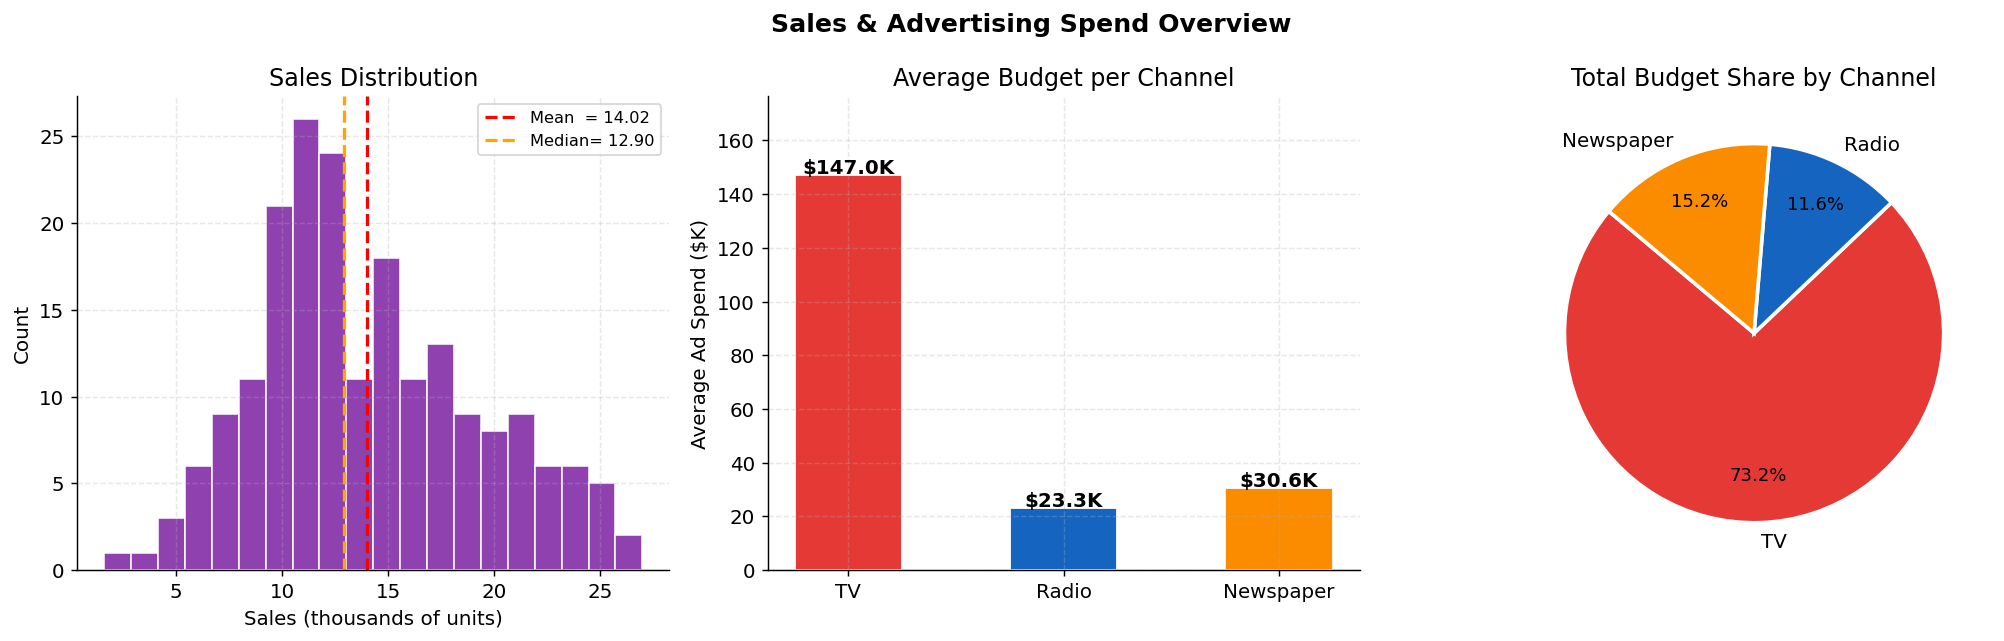

✅ Saved → /content/sales_plots/fig1_overview.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Sales & Advertising Spend Overview", fontsize=14, fontweight="bold")

# Sales distribution
ax1 = axes[0]
ax1.hist(df[TARGET], bins=20, color="#7B1FA2", alpha=0.85, edgecolor="white")
ax1.axvline(df[TARGET].mean(),   color="red",    linestyle="--", lw=1.8,
            label=f"Mean  = {df[TARGET].mean():.2f}")
ax1.axvline(df[TARGET].median(), color="orange", linestyle="--", lw=1.8,
            label=f"Median= {df[TARGET].median():.2f}")
ax1.set_xlabel("Sales (thousands of units)")
ax1.set_ylabel("Count"); ax1.set_title("Sales Distribution"); ax1.legend(fontsize=9)

# Average spend per channel
ax2 = axes[1]
ch_means = df[CHANNELS].mean()
bars = ax2.bar(CHANNELS, ch_means,
               color=[PALETTE.get(c,"gray") for c in CHANNELS],
               edgecolor="white", width=0.5)
for bar, val in zip(bars, ch_means):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f"${val:.1f}K", ha="center", fontsize=11, fontweight="bold")
ax2.set_ylabel("Average Ad Spend ($K)"); ax2.set_title("Average Budget per Channel")
ax2.set_ylim(0, ch_means.max() * 1.2)

# Budget share pie
ax3 = axes[2]
total_by_ch = df[CHANNELS].sum()
wedges, texts, autotexts = ax3.pie(
    total_by_ch, labels=CHANNELS,
    colors=[PALETTE.get(c,"gray") for c in CHANNELS],
    autopct="%1.1f%%", startangle=140, pctdistance=0.75,
    wedgeprops={"edgecolor":"white","linewidth":2})
for t in texts:     t.set_fontsize(11)
for t in autotexts: t.set_fontsize(10)
ax3.set_title("Total Budget Share by Channel")

plt.tight_layout()
SAVE1 = f"{SAVE_DIR}/fig1_overview.png"
plt.savefig(SAVE1, bbox_inches="tight"); plt.show()
print(f"✅ Saved → {SAVE1}")


## 6.  Advertising Impact Analysis — Channel vs Sales

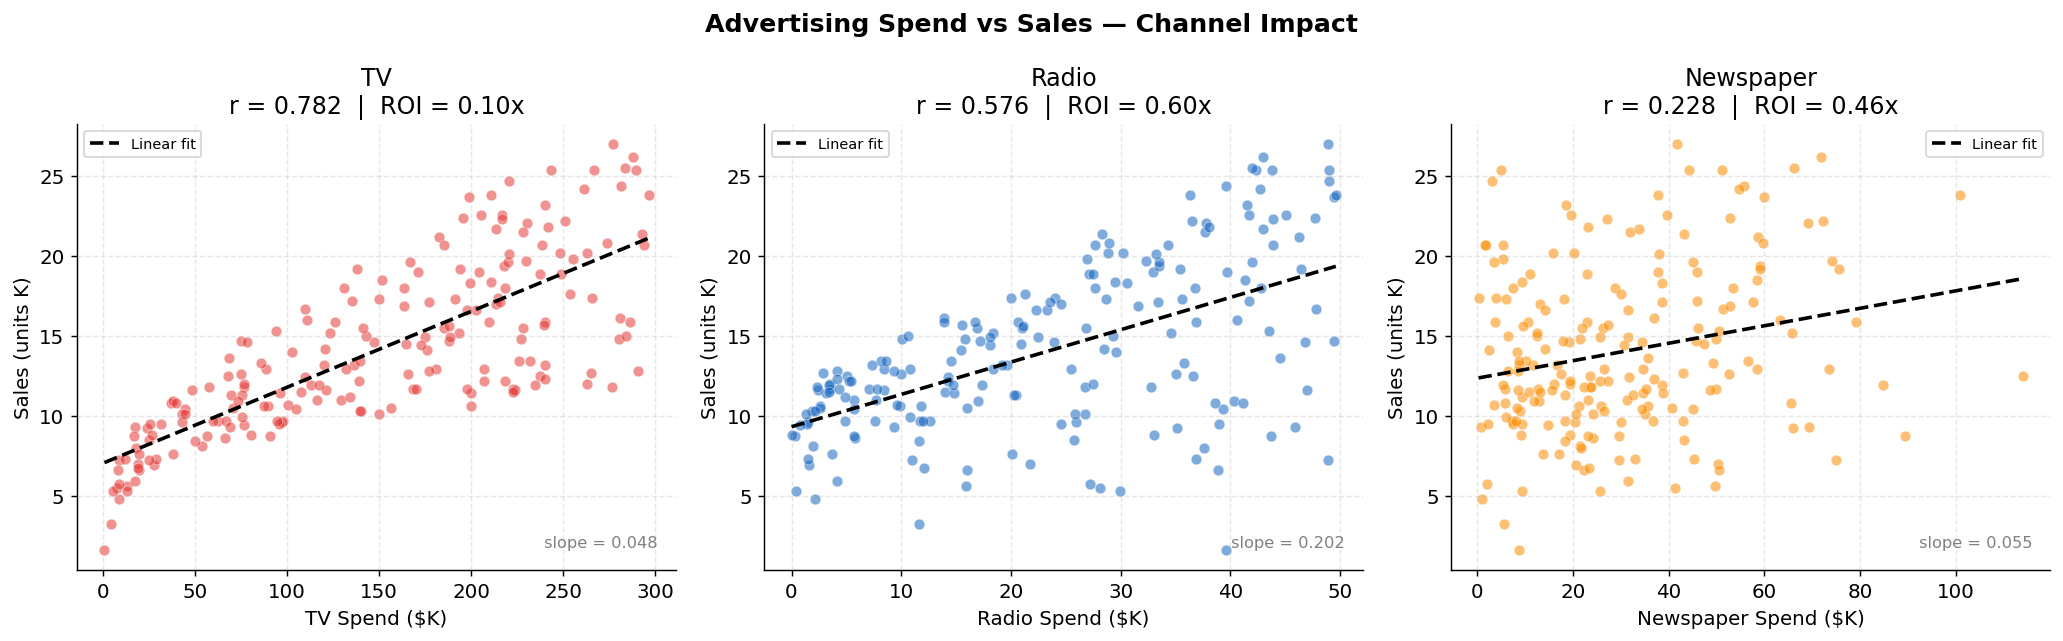

✅ Saved → /content/sales_plots/fig2_ad_impact.png

📊 Channel ROI Summary:
  Channel        Correlation      ROI   Sales per $K
  --------------------------------------------------
  TV                  0.7822    0.095x        0.0475 units/$K
  Radio               0.5762    0.603x        0.2025 units/$K
  Newspaper           0.2283    0.459x        0.0547 units/$K


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Advertising Spend vs Sales — Channel Impact",
             fontsize=14, fontweight="bold")

for ax, ch in zip(axes, CHANNELS):
    color = PALETTE.get(ch, "gray")
    ax.scatter(df[ch], df[TARGET], alpha=0.55, s=35,
               color=color, edgecolors="white", linewidths=0.4)

    # Regression line
    m, b = np.polyfit(df[ch], df[TARGET], 1)
    xs   = np.linspace(df[ch].min(), df[ch].max(), 200)
    ax.plot(xs, m*xs+b, color="black", linestyle="--", linewidth=2, label="Linear fit")

    r   = df[ch].corr(df[TARGET])
    roi = df[TARGET].sum() / df[ch].sum()

    ax.set_xlabel(f"{ch} Spend ($K)")
    ax.set_ylabel("Sales (units K)")
    ax.set_title(f"{ch}\nr = {r:.3f}  |  ROI = {roi:.2f}x")
    ax.text(0.97, 0.05, f"slope = {m:.3f}", transform=ax.transAxes,
            ha="right", fontsize=9, color="gray")
    ax.legend(fontsize=8)

plt.tight_layout()
SAVE2 = f"{SAVE_DIR}/fig2_ad_impact.png"
plt.savefig(SAVE2, bbox_inches="tight"); plt.show()
print(f"✅ Saved → {SAVE2}")

print("\n📊 Channel ROI Summary:")
print(f"  {'Channel':<12} {'Correlation':>13} {'ROI':>8} {'Sales per $K':>14}")
print("  " + "-" * 50)
for ch in CHANNELS:
    r   = df[ch].corr(df[TARGET])
    roi = df[TARGET].sum() / df[ch].sum()
    m,_ = np.polyfit(df[ch], df[TARGET], 1)
    print(f"  {ch:<12} {r:>13.4f} {roi:>8.3f}x {m:>13.4f} units/$K")


## 7.  Correlation Analysis

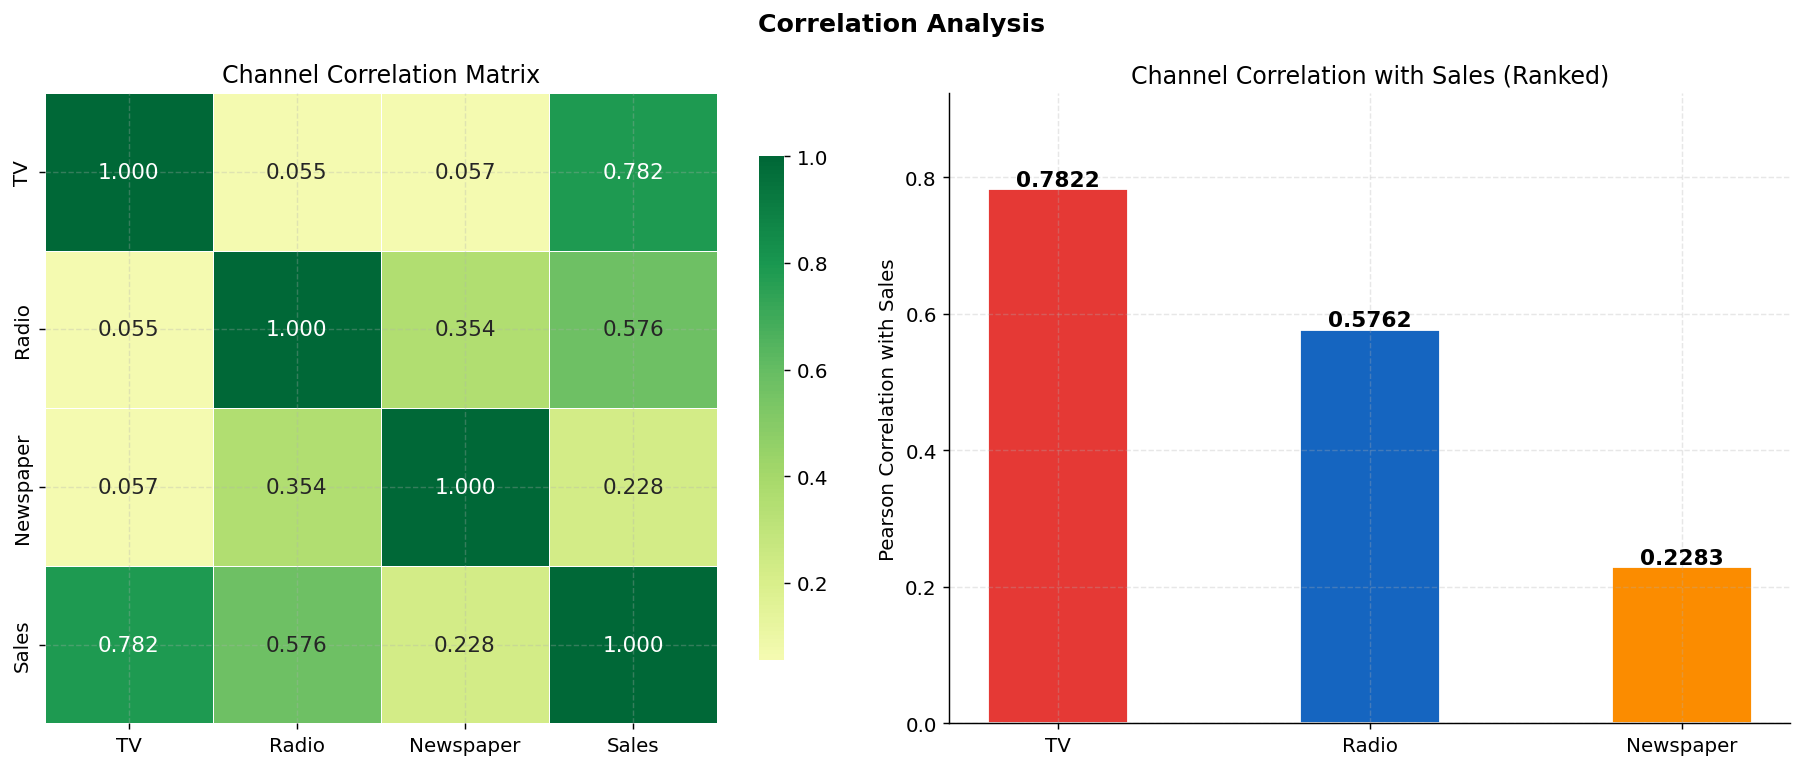

✅ Saved → /content/sales_plots/fig3_correlation.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Correlation Analysis", fontsize=14, fontweight="bold")

# Heatmap — core columns
core_cols = CHANNELS + [TARGET]
corr = df[core_cols].corr()
sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdYlGn", center=0,
            linewidths=0.5, ax=axes[0], cbar_kws={"shrink":0.8},
            annot_kws={"size":12})
axes[0].set_title("Channel Correlation Matrix")

# Ranked bar — correlation with Sales
ch_corrs  = {ch: df[ch].corr(df[TARGET]) for ch in CHANNELS}
sorted_ch = dict(sorted(ch_corrs.items(), key=lambda x: x[1], reverse=True))
bars = axes[1].bar(list(sorted_ch.keys()), list(sorted_ch.values()),
                   color=[PALETTE.get(c,"gray") for c in sorted_ch],
                   edgecolor="white", width=0.45)
for bar, val in zip(bars, sorted_ch.values()):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f"{val:.4f}", ha="center", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Pearson Correlation with Sales")
axes[1].set_title("Channel Correlation with Sales (Ranked)")
axes[1].set_ylim(0, max(sorted_ch.values()) * 1.18)

plt.tight_layout()
SAVE3 = f"{SAVE_DIR}/fig3_correlation.png"
plt.savefig(SAVE3, bbox_inches="tight"); plt.show()
print(f"✅ Saved → {SAVE3}")


## 8. Pairplot — All Features

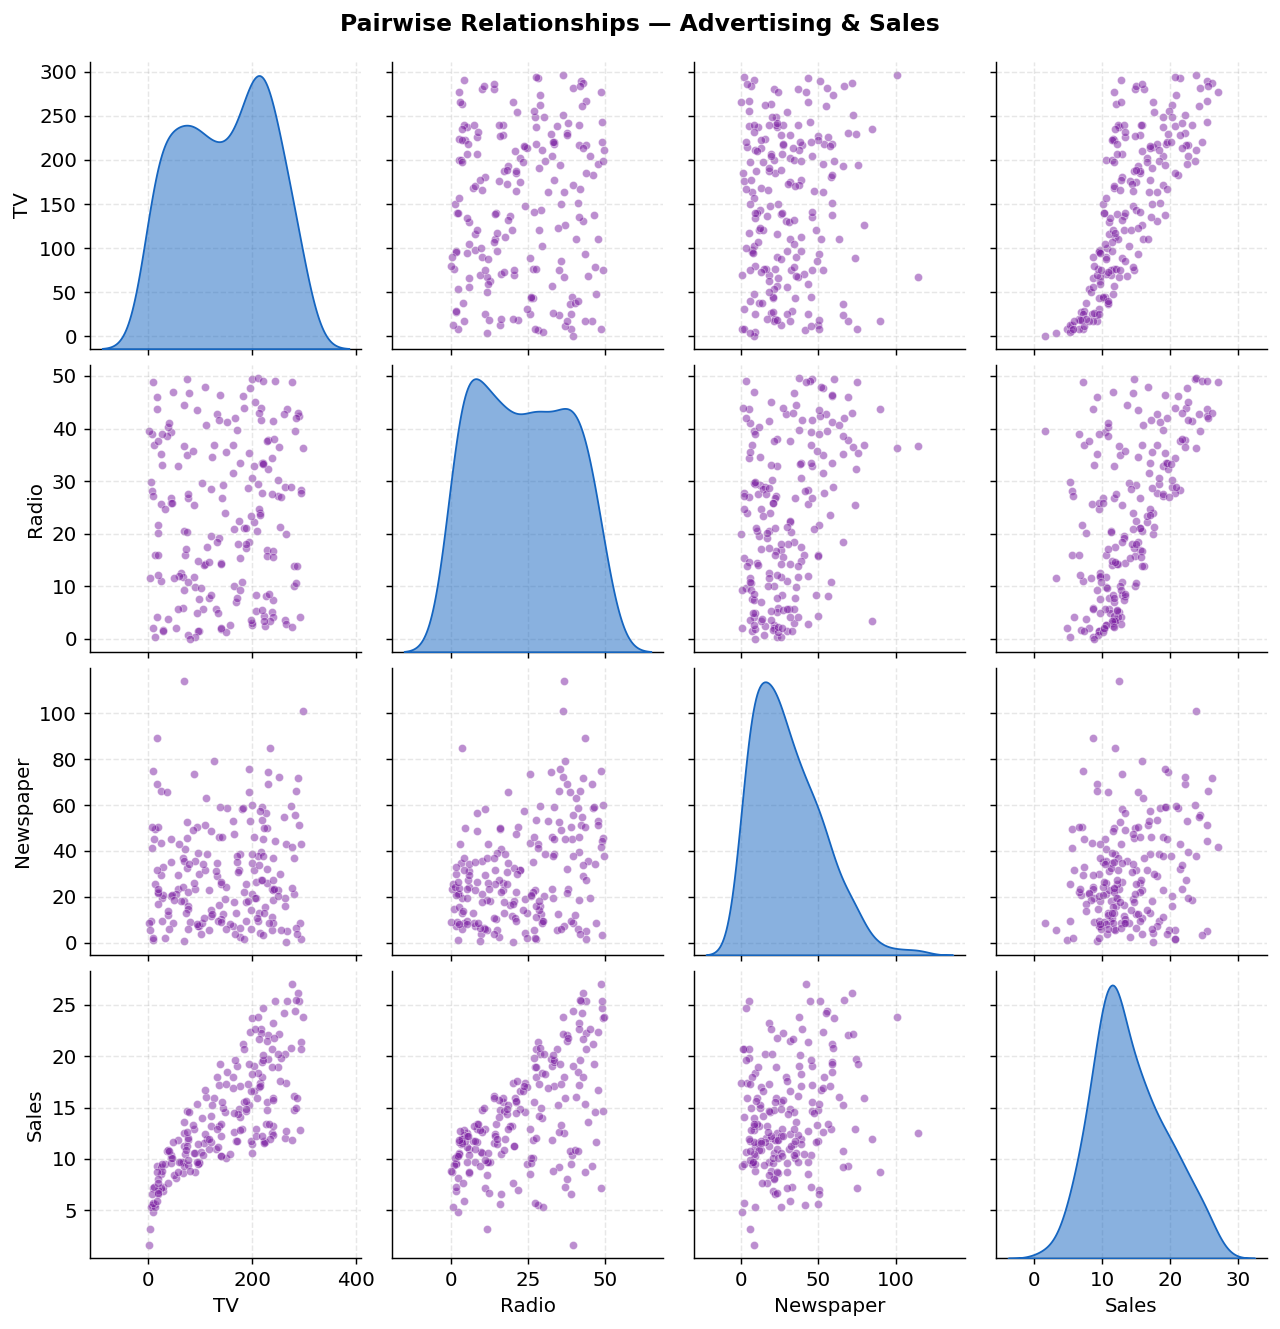

✅ Saved → /content/sales_plots/fig4_pairplot.png


In [9]:
pp_df = df[CHANNELS + [TARGET]].copy()
pp = sns.pairplot(pp_df, diag_kind="kde",
                  plot_kws={"alpha":0.5, "s":20, "color":"#7B1FA2"},
                  diag_kws={"color":"#1565C0", "fill":True, "alpha":0.5})
pp.figure.suptitle("Pairwise Relationships — Advertising & Sales",
                   fontsize=13, fontweight="bold", y=1.02)

SAVE4 = f"{SAVE_DIR}/fig4_pairplot.png"
pp.figure.savefig(SAVE4, bbox_inches="tight"); plt.show()
print(f"✅ Saved → {SAVE4}")


## 9.  Preprocessing & Train/Test Split

In [10]:
feature_cols = CHANNELS + ["Total_Spend","TV_Radio","TV_News",
                            "Radio_News","log_TV","log_Radio",
                            "TV_share","Radio_share","Newspaper_share"]
feature_cols = [c for c in feature_cols if c in df.columns]

X = df[feature_cols]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"✅ Preprocessing complete!")
print(f"   Total samples : {len(df)}")
print(f"   Train samples : {X_train.shape[0]}")
print(f"   Test samples  : {X_test.shape[0]}")
print(f"   Features used : {X.shape[1]}")
print(f"   Feature list  : {feature_cols}")


✅ Preprocessing complete!
   Total samples : 200
   Train samples : 160
   Test samples  : 40
   Features used : 12
   Feature list  : ['TV', 'Radio', 'Newspaper', 'Total_Spend', 'TV_Radio', 'TV_News', 'Radio_News', 'log_TV', 'log_Radio', 'TV_share', 'Radio_share', 'Newspaper_share']


## 10.  Train & Compare 6 Models

In [11]:
models = {
    "Linear Regression"  : LinearRegression(),
    "Ridge Regression"   : Ridge(alpha=1.0),
    "Lasso Regression"   : Lasso(alpha=0.01),
    "Decision Tree"      : DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest"      : RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting"  : GradientBoostingRegressor(n_estimators=200,
                                                      learning_rate=0.05,
                                                      max_depth=3, random_state=42),
}

results = {}
print(f"{'Model':<22} {'R²':>8} {'MAE':>8} {'RMSE':>8} {'CV R²':>10}")
print("-" * 62)

for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    r2     = r2_score(y_test, y_pred)
    mae    = mean_absolute_error(y_test, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    cv_r2  = cross_val_score(model, scaler.fit_transform(X), y,
                              cv=5, scoring="r2").mean()
    results[name] = {"model":model,"y_pred":y_pred,
                     "r2":r2,"mae":mae,"rmse":rmse,"cv_r2":cv_r2}
    star = "★" if r2 == max(r["r2"] for r in results.values()) else " "
    print(f"  {star} {name:<20} {r2:>8.4f} {mae:>8.3f} {rmse:>8.3f} {cv_r2:>10.4f}")

best_name = max(results, key=lambda k: results[k]["r2"])
best      = results[best_name]
print(f"\n  ★ Best Model: {best_name}  (R² = {best['r2']:.4f})")


Model                        R²      MAE     RMSE      CV R²
--------------------------------------------------------------
  ★ Linear Regression      0.9951    0.312    0.395     0.9958
    Ridge Regression       0.9942    0.325    0.428     0.9956
  ★ Lasso Regression       0.9955    0.297    0.378     0.9960
    Decision Tree          0.9720    0.710    0.940     0.9728
    Random Forest          0.9879    0.473    0.617     0.9873
    Gradient Boosting      0.9867    0.481    0.648     0.9887

  ★ Best Model: Lasso Regression  (R² = 0.9955)


## 11. 📊 Model Comparison Charts

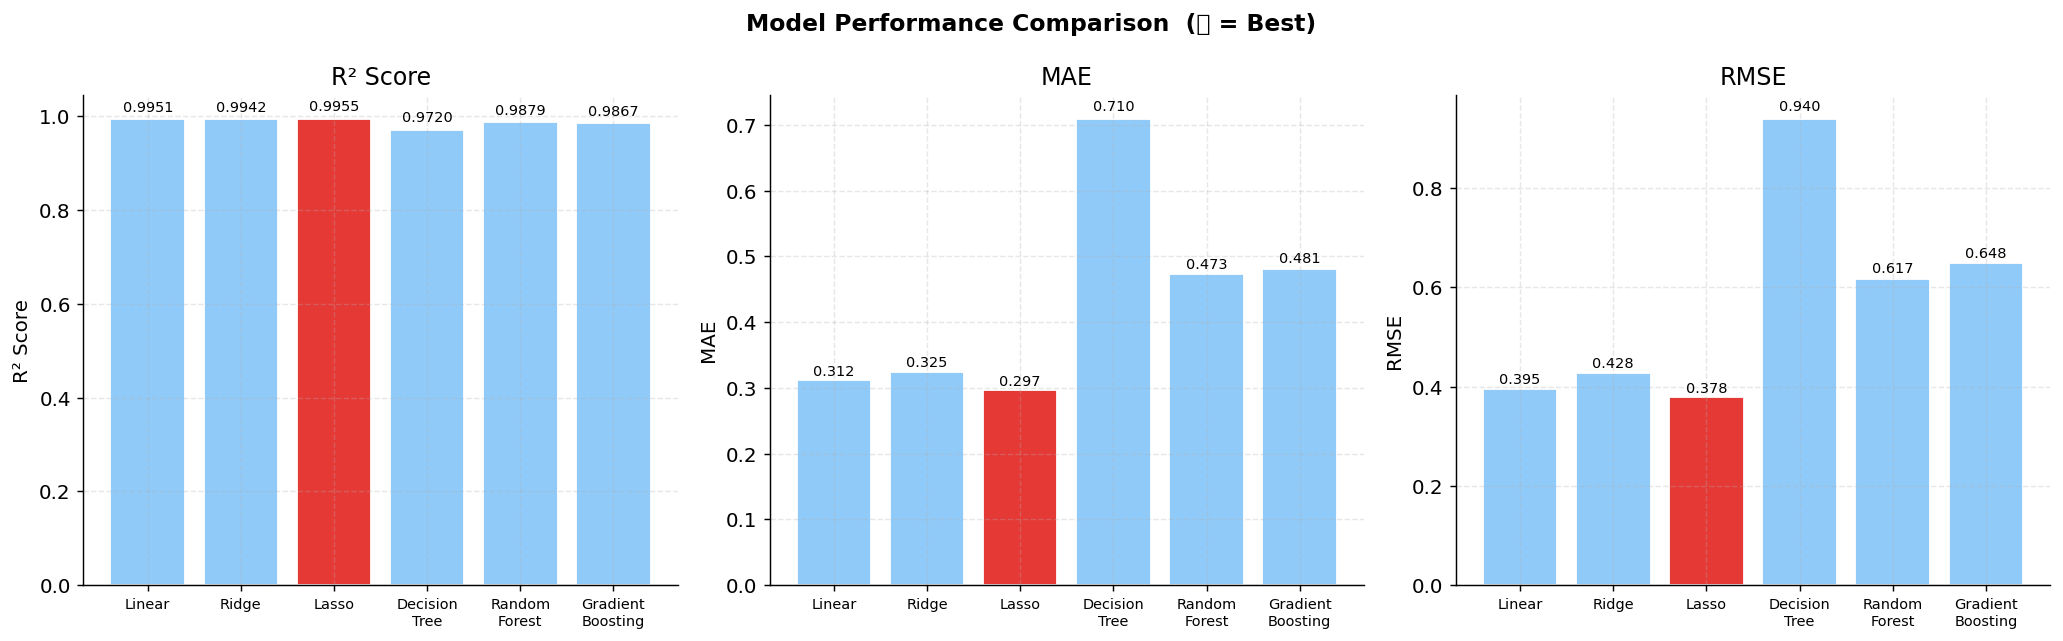

✅ Saved → /content/sales_plots/fig5_model_comparison.png


In [12]:
names      = list(results.keys())
short      = [n.replace(" Regression","").replace(" ","\n") for n in names]
bar_colors = ["#E53935" if n==best_name else "#90CAF9" for n in names]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Model Performance Comparison  (🔴 = Best)",
             fontsize=13, fontweight="bold")

metrics = [
    ([results[n]["r2"]    for n in names], "R² Score"),
    ([results[n]["mae"]   for n in names], "MAE"),
    ([results[n]["rmse"]  for n in names], "RMSE"),
]
for ax, (vals, label) in zip(axes, metrics):
    bars = ax.bar(short, vals, color=bar_colors, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                f"{v:.4f}" if "R²" in label else f"{v:.3f}",
                ha="center", va="bottom", fontsize=8)
    ax.set_title(label); ax.set_ylabel(label)
    ax.tick_params(axis="x", labelsize=8)

plt.tight_layout()
SAVE5 = f"{SAVE_DIR}/fig5_model_comparison.png"
plt.savefig(SAVE5, bbox_inches="tight"); plt.show()
print(f"✅ Saved → {SAVE5}")


## 12. 🎯 Actual vs Predicted & Residual Analysis

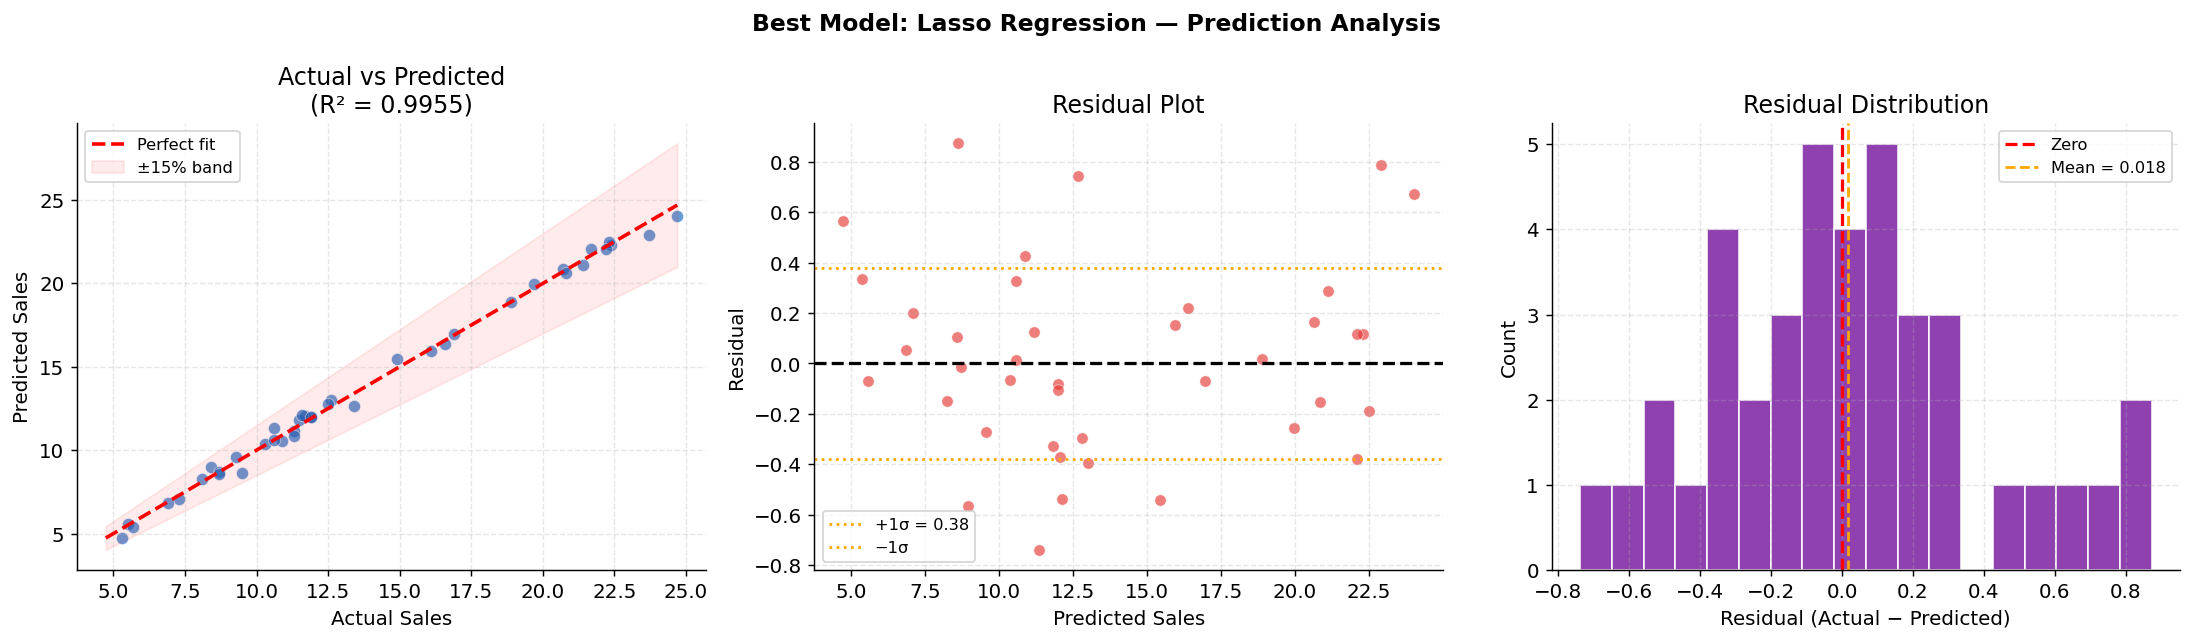

✅ Saved → /content/sales_plots/fig6_actual_vs_predicted.png

   MAE       : 0.2969 units
   RMSE      : 0.3780 units
   Residual σ: 0.3776  (lower = more consistent)


In [13]:
y_pred_best = best["y_pred"]
residuals   = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(f"Best Model: {best_name} — Prediction Analysis",
             fontsize=13, fontweight="bold")

# Actual vs Predicted scatter
ax1 = axes[0]
mn, mx = min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())
ax1.scatter(y_test, y_pred_best, alpha=0.65, s=45, color="#1565C0",
            edgecolors="white", linewidths=0.4)
ax1.plot([mn,mx],[mn,mx], "r--", linewidth=2, label="Perfect fit")
ax1.fill_between([mn,mx],[mn*0.85,mx*0.85],[mn*1.15,mx*1.15],
                 alpha=0.08, color="red", label="±15% band")
ax1.set_xlabel("Actual Sales"); ax1.set_ylabel("Predicted Sales")
ax1.set_title(f"Actual vs Predicted\n(R² = {best['r2']:.4f})")
ax1.legend(fontsize=9)

# Residual scatter
ax2 = axes[1]
ax2.scatter(y_pred_best, residuals, alpha=0.65, s=40, color="#E53935",
            edgecolors="white", linewidths=0.4)
ax2.axhline(0, color="black", linestyle="--", linewidth=1.8)
ax2.axhline(residuals.std(),  color="orange", linestyle=":", linewidth=1.5,
            label=f"+1σ = {residuals.std():.2f}")
ax2.axhline(-residuals.std(), color="orange", linestyle=":", linewidth=1.5,
            label=f"−1σ")
ax2.set_xlabel("Predicted Sales"); ax2.set_ylabel("Residual")
ax2.set_title("Residual Plot"); ax2.legend(fontsize=9)

# Residual histogram
ax3 = axes[2]
ax3.hist(residuals, bins=18, color="#7B1FA2", alpha=0.85, edgecolor="white")
ax3.axvline(0,                color="red",    linestyle="--", lw=1.8, label="Zero")
ax3.axvline(residuals.mean(), color="orange", linestyle="--", lw=1.5,
            label=f"Mean = {residuals.mean():.3f}")
ax3.set_xlabel("Residual (Actual − Predicted)")
ax3.set_ylabel("Count"); ax3.set_title("Residual Distribution")
ax3.legend(fontsize=9)

plt.tight_layout()
SAVE6 = f"{SAVE_DIR}/fig6_actual_vs_predicted.png"
plt.savefig(SAVE6, bbox_inches="tight"); plt.show()
print(f"✅ Saved → {SAVE6}")
print(f"\n   MAE       : {best['mae']:.4f} units")
print(f"   RMSE      : {best['rmse']:.4f} units")
print(f"   Residual σ: {residuals.std():.4f}  (lower = more consistent)")


## 13. Feature Importance

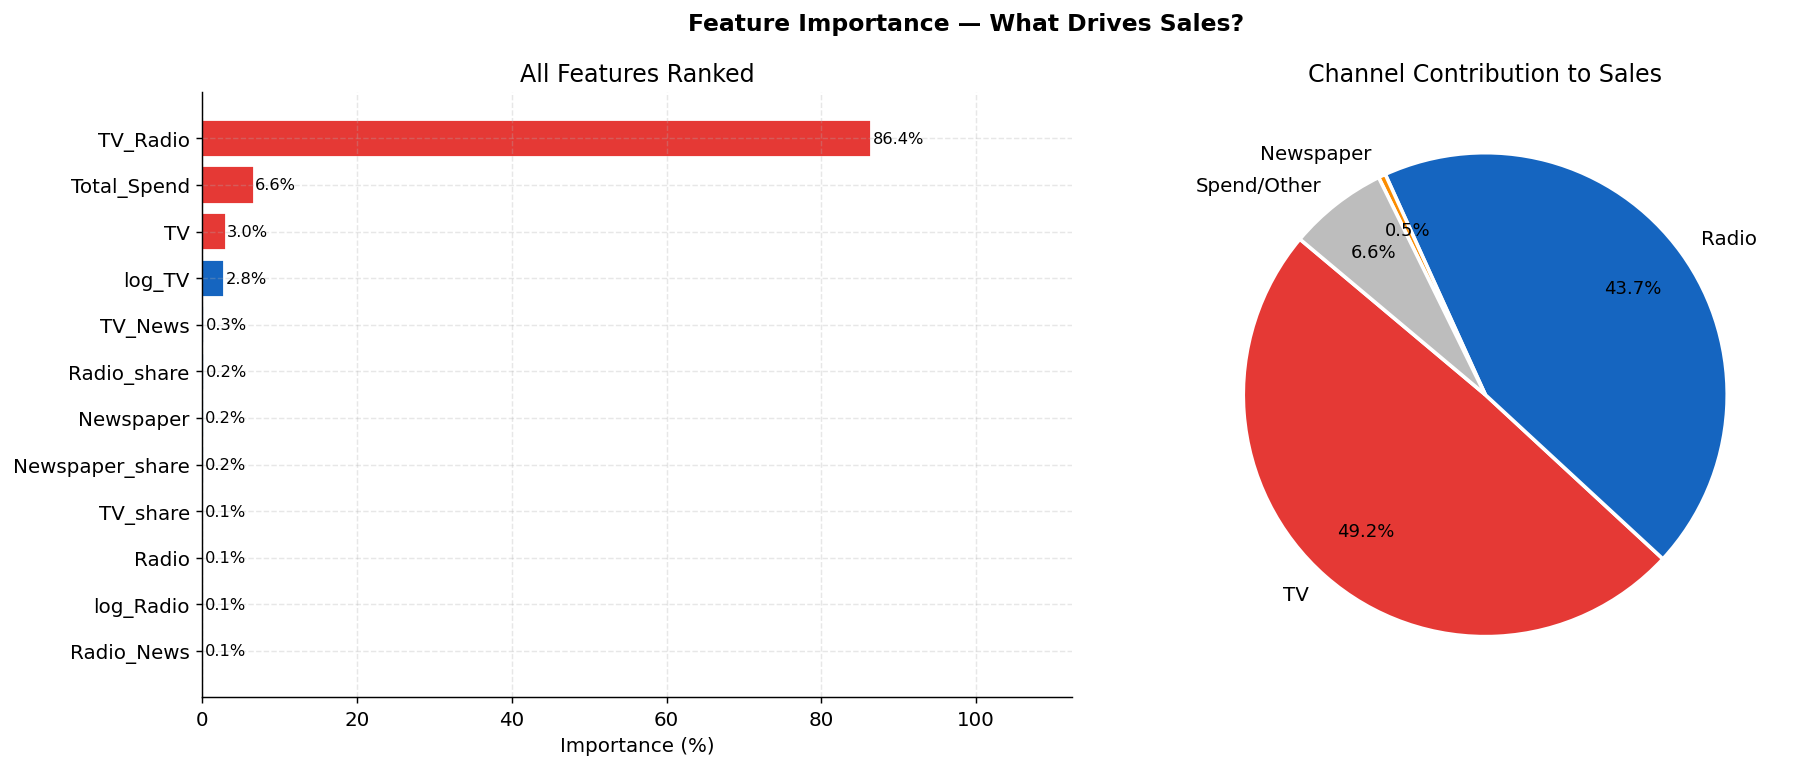

✅ Saved → /content/sales_plots/fig7_feature_importance.png

Top Feature Importances:
  TV_Radio              86.4%  ██████████████████████████████████████████████████████████████████████████████████████
  Total_Spend           6.6%  ██████
  TV                    3.0%  ██
  log_TV                2.8%  ██
  TV_News               0.3%  
  Radio_share           0.2%  


In [14]:
rf_model = results["Random Forest"]["model"]
feat_imp = pd.Series(rf_model.feature_importances_,
                     index=feature_cols).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Feature Importance — What Drives Sales?",
             fontsize=13, fontweight="bold")

# Bar chart
colors_imp = ["#E53935" if i<3 else "#1565C0" if i<6 else "#90CAF9"
              for i in range(len(feat_imp))]
axes[0].barh(feat_imp.index[::-1], feat_imp.values[::-1]*100,
             color=colors_imp[::-1], edgecolor="white")
for i, (idx, val) in enumerate(zip(feat_imp.index[::-1], feat_imp.values[::-1])):
    axes[0].text(val*100+0.2, i, f"{val*100:.1f}%", va="center", fontsize=9)
axes[0].set_xlabel("Importance (%)")
axes[0].set_title("All Features Ranked")
axes[0].set_xlim(0, feat_imp.values.max()*130)

# Channel-only aggregated pie
ch_agg = {}
ch_agg["TV"]        = feat_imp.get("TV",0)+feat_imp.get("log_TV",0)+feat_imp.get("TV_share",0)+feat_imp.get("TV_Radio",0)*0.5+feat_imp.get("TV_News",0)*0.5
ch_agg["Radio"]     = feat_imp.get("Radio",0)+feat_imp.get("log_Radio",0)+feat_imp.get("Radio_share",0)+feat_imp.get("TV_Radio",0)*0.5+feat_imp.get("Radio_News",0)*0.5
ch_agg["Newspaper"] = feat_imp.get("Newspaper",0)+feat_imp.get("Newspaper_share",0)+feat_imp.get("TV_News",0)*0.5+feat_imp.get("Radio_News",0)*0.5
ch_agg["Spend/Other"] = feat_imp.get("Total_Spend",0)
ch_agg = {k: max(v, 0.001) for k, v in ch_agg.items()}

pie_colors = [PALETTE.get(k,"#BDBDBD") for k in ch_agg]
wedges, texts, autotexts = axes[1].pie(
    ch_agg.values(), labels=ch_agg.keys(), colors=pie_colors,
    autopct="%1.1f%%", startangle=140, pctdistance=0.75,
    wedgeprops={"edgecolor":"white","linewidth":2})
for t in texts:     t.set_fontsize(11)
for t in autotexts: t.set_fontsize(10)
axes[1].set_title("Channel Contribution to Sales")

plt.tight_layout()
SAVE7 = f"{SAVE_DIR}/fig7_feature_importance.png"
plt.savefig(SAVE7, bbox_inches="tight"); plt.show()
print(f"✅ Saved → {SAVE7}")

print("\nTop Feature Importances:")
for feat, imp in feat_imp.head(6).items():
    bar = "█" * int(imp * 100)
    print(f"  {feat:<20}  {imp*100:.1f}%  {bar}")


  🔮 SALES FORECAST — WHAT-IF SCENARIOS
  Scenario                                TV   Radio   News   Pred Sales
  --------------------------------------------------------------
  Balanced (equal thirds)             $  100K $  100K $ 100K      22.99 units
  TV Heavy                            $  250K $   50K $  50K      26.27 units
  Radio Heavy                         $   50K $  200K $  50K      23.12 units
  Digital-only (no Newspaper)         $  150K $  150K $   0K      26.54 units
  Low Budget                          $   50K $   30K $  20K      10.92 units
  High Budget (all channels)          $  250K $  100K $  50K      26.75 units


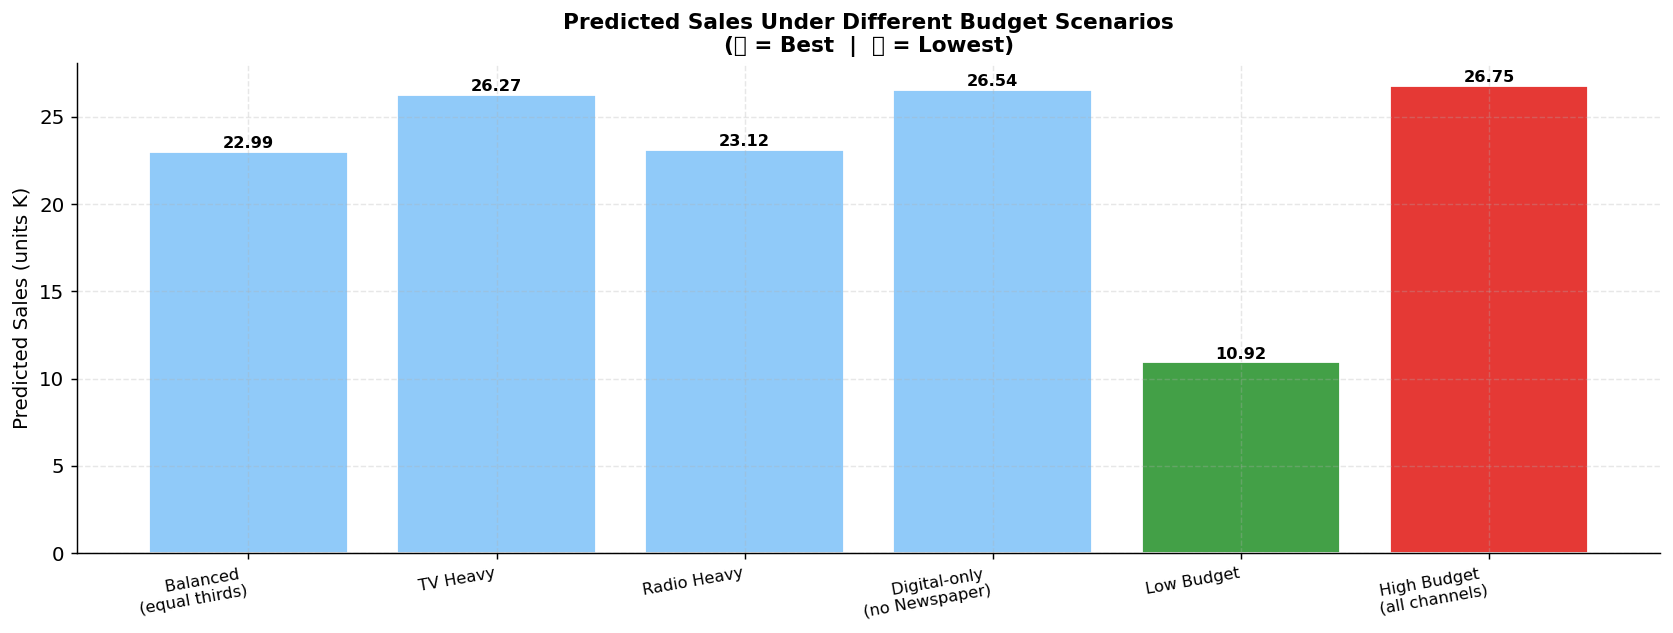


✅ Saved → /content/sales_plots/fig8_whatif_forecast.png


In [15]:
gb_model = results["Gradient Boosting"]["model"]

def make_features(tv, radio, newspaper):
    total  = tv + radio + newspaper
    row = {
        "TV":tv, "Radio":radio, "Newspaper":newspaper,
        "Total_Spend":total,
        "TV_Radio":tv*radio, "TV_News":tv*newspaper, "Radio_News":radio*newspaper,
        "log_TV":np.log1p(tv), "log_Radio":np.log1p(radio),
        "TV_share":tv/(total+1e-6)*100,
        "Radio_share":radio/(total+1e-6)*100,
        "Newspaper_share":newspaper/(total+1e-6)*100,
    }
    sample = pd.DataFrame([row])[feature_cols]
    return scaler.transform(sample.fillna(0))

scenarios = [
    ("Balanced (equal thirds)",      100, 100, 100),
    ("TV Heavy",                     250, 50,  50),
    ("Radio Heavy",                  50,  200, 50),
    ("Digital-only (no Newspaper)",  150, 150, 0),
    ("Low Budget",                   50,  30,  20),
    ("High Budget (all channels)",   250, 100, 50),
]

print("=" * 62)
print("  🔮 SALES FORECAST — WHAT-IF SCENARIOS")
print("=" * 62)
print(f"  {'Scenario':<35} {'TV':>6} {'Radio':>7} {'News':>6} {'Pred Sales':>12}")
print("  " + "-"*62)

sc_names, sc_sales = [], []
for label, tv, radio, newspaper in scenarios:
    feat  = make_features(tv, radio, newspaper)
    pred  = gb_model.predict(feat)[0]
    sc_names.append(label)
    sc_sales.append(pred)
    print(f"  {label:<35} ${tv:>5}K ${radio:>5}K ${newspaper:>4}K   {pred:>8.2f} units")

# Bar chart of scenarios
fig, ax = plt.subplots(figsize=(13, 5))
colors_sc = ["#E53935" if s == max(sc_sales) else
             "#43A047" if s == min(sc_sales) else "#90CAF9" for s in sc_sales]
bars = ax.bar(range(len(sc_names)), sc_sales, color=colors_sc, edgecolor="white")
ax.set_xticks(range(len(sc_names)))
ax.set_xticklabels([n.replace("(",  "\n(") for n in sc_names], fontsize=9, rotation=10, ha="right")
for bar, val in zip(bars, sc_sales):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f"{val:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_ylabel("Predicted Sales (units K)")
ax.set_title("Predicted Sales Under Different Budget Scenarios\n(🔴 = Best  |  🟢 = Lowest)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
SAVE8 = f"{SAVE_DIR}/fig8_whatif_forecast.png"
plt.savefig(SAVE8, bbox_inches="tight"); plt.show()
print(f"\n✅ Saved → {SAVE8}")


## 15. 💡 Budget Simulation — Sales Response Curves

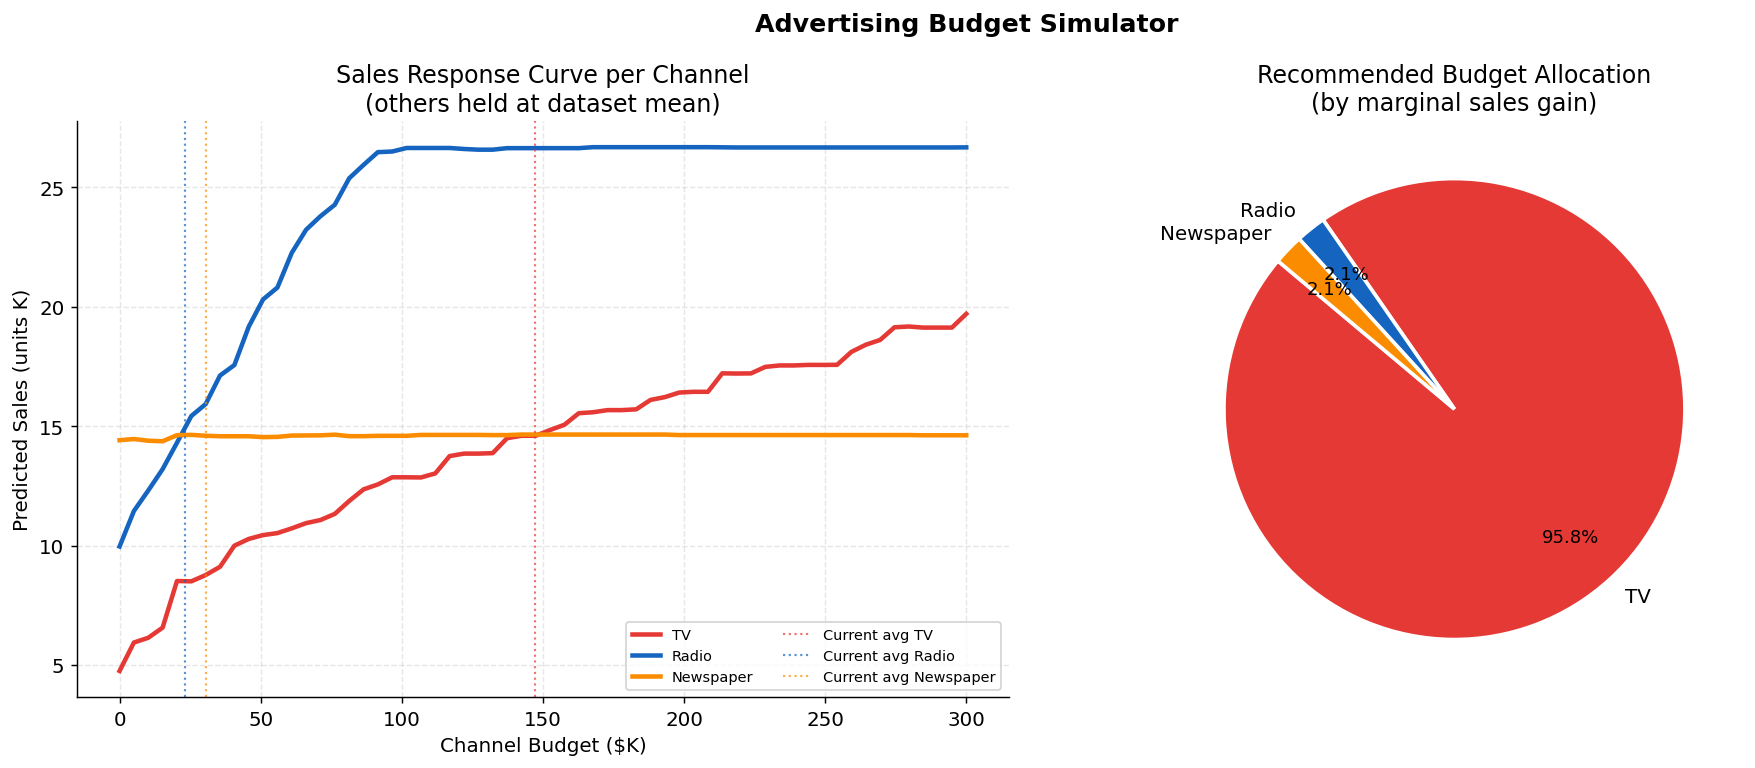

✅ Saved → /content/sales_plots/fig9_budget_simulation.png

💡 Marginal Sales Gain per $K spent (at median budget):
   TV            0.0453 units per $K  →  recommended share: 95.8%
   Radio         0.0010 units per $K  →  recommended share: 2.1%
   Newspaper     0.0010 units per $K  →  recommended share: 2.1%


In [16]:
budgets = np.linspace(0, 300, 60)
base_tv    = df["TV"].mean()
base_radio = df["Radio"].mean()
base_news  = df["Newspaper"].mean()

response = {}
for ch in CHANNELS:
    preds = []
    for b in budgets:
        tv    = b          if ch=="TV"        else base_tv
        radio = b          if ch=="Radio"     else base_radio
        news  = b          if ch=="Newspaper" else base_news
        feat  = make_features(tv, radio, news)
        preds.append(gb_model.predict(feat)[0])
    response[ch] = preds

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Advertising Budget Simulator", fontsize=14, fontweight="bold")

# Response curves
ax1 = axes[0]
for ch in CHANNELS:
    ax1.plot(budgets, response[ch], linewidth=2.5,
             label=ch, color=PALETTE.get(ch,"gray"))
ax1.axvline(df["TV"].mean(),        color=PALETTE["TV"],        linestyle=":",
            linewidth=1.2, alpha=0.7, label="Current avg TV")
ax1.axvline(df["Radio"].mean(),     color=PALETTE["Radio"],     linestyle=":",
            linewidth=1.2, alpha=0.7, label="Current avg Radio")
ax1.axvline(df["Newspaper"].mean(), color=PALETTE["Newspaper"], linestyle=":",
            linewidth=1.2, alpha=0.7, label="Current avg Newspaper")
ax1.set_xlabel("Channel Budget ($K)")
ax1.set_ylabel("Predicted Sales (units K)")
ax1.set_title("Sales Response Curve per Channel\n(others held at dataset mean)")
ax1.legend(fontsize=8, ncol=2)

# Marginal return — slope at midpoint
ax2 = axes[1]
mid   = len(budgets)//2
gains = {}
for ch in CHANNELS:
    slope = (response[ch][mid+1] - response[ch][mid-1]) / (budgets[mid+1] - budgets[mid-1])
    gains[ch] = max(slope, 0.001)

total_gain = sum(gains.values())
alloc = {ch: g/total_gain*100 for ch, g in gains.items()}

wedges, texts, autotexts = ax2.pie(
    alloc.values(), labels=alloc.keys(),
    colors=[PALETTE.get(c,"gray") for c in alloc],
    autopct="%1.1f%%", startangle=140, pctdistance=0.75,
    wedgeprops={"edgecolor":"white","linewidth":2})
for t in texts:     t.set_fontsize(11)
for t in autotexts: t.set_fontsize(10)
ax2.set_title("Recommended Budget Allocation\n(by marginal sales gain)")

plt.tight_layout()
SAVE9 = f"{SAVE_DIR}/fig9_budget_simulation.png"
plt.savefig(SAVE9, bbox_inches="tight"); plt.show()
print(f"✅ Saved → {SAVE9}")

print("\n💡 Marginal Sales Gain per $K spent (at median budget):")
for ch, g in sorted(gains.items(), key=lambda x: x[1], reverse=True):
    print(f"   {ch:<12}  {g:.4f} units per $K  →  recommended share: {alloc[ch]:.1f}%")
